# Task 2 — Standalone Corruption Classifier and Hard-Routed Specialists

A self-contained implementation of Task 2 (classification plus hard-routed restoration). It trains a four-class corruption classifier and three independently parameterized restoration autoencoders for salt-and-pepper noise, Gaussian blur, and rectangular occlusion. Clean inputs use an identity bypass and have no restoration expert.

The notebook imports no project-specific Python modules. It reads the repository's official Oxford-IIIT Pet split and local image files, creates runtime training corruptions, persists deterministic validation/test manifests, performs the required Optuna searches, reports classifier metrics, and compares oracle routing with predicted routing. It also saves trained checkpoints and a JSON run report.


## 1. Configuration, imports, and data paths

In [1]:
from pathlib import Path
import json, math, random, copy
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics.functional import structural_similarity_index_measure
import optuna

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
REPO_ROOT = next(
    (
        p
        for p in _candidates
        if (p / "research/datasets/oxford-iiit-pet/images").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate research/datasets/oxford-iiit-pet/images")
RESEARCH_ROOT = REPO_ROOT / "research"
IMAGE_DIR = RESEARCH_ROOT / "datasets/oxford-iiit-pet/images"
SPLIT_PATH = RESEARCH_ROOT / "split_manifest_official.json"
if not SPLIT_PATH.is_file():
    raise FileNotFoundError(f"Official split manifest missing: {SPLIT_PATH}")
with SPLIT_PATH.open() as f:
    SPLITS = json.load(f)

IMAGE_SIZE = 128
SEED = 42
CLASSES = ("clean", "salt", "blur", "occlusion")
RESTORATION_CLASSES = ("salt", "blur", "occlusion")
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASSES)}
BATCH_SIZE = 64
NUM_WORKERS = 2
# Adjust these for available compute. Tiny mode is for pipeline checks only.
N_CLASSIFIER_TRIALS, CLASSIFIER_SEARCH_EPOCHS, CLASSIFIER_FINAL_EPOCHS = 20, 5, 35
N_SPECIALIST_TRIALS, SPECIALIST_SEARCH_EPOCHS, SPECIALIST_FINAL_EPOCHS = 20, 5, 35
TINY_RUN = False
TINY_SIZE = 64
if TINY_RUN:
    N_CLASSIFIER_TRIALS, CLASSIFIER_SEARCH_EPOCHS, CLASSIFIER_FINAL_EPOCHS = 2, 1, 2
    N_SPECIALIST_TRIALS, SPECIALIST_SEARCH_EPOCHS, SPECIALIST_FINAL_EPOCHS = 2, 1, 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("Device:", device, "| Dataset:", IMAGE_DIR)
print({k: len(SPLITS[k]) for k in ("train", "val", "test")})


Device: cuda | Dataset: /home/zaifi/genai-assignment-1/research/datasets/oxford-iiit-pet/images
{'train': 2944, 'val': 736, 'test': 3669}


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Corruptions, balanced labels, and deterministic manifests

Classifier training samples one of four labels uniformly for each image. Validation includes every class for every validation image, ensuring a balanced, repeatable score. Each specialist sees only its assigned corruption during training and validation.

In [2]:
BENCHMARKS = {
    "clean": [{"severity": "none"}],
    "salt": [
        {"severity": "low", "prob": 0.03},
        {"severity": "medium", "prob": 0.08},
        {"severity": "high", "prob": 0.15},
    ],
    "blur": [
        {"severity": "low", "kernel_size": 3, "sigma": 0.7},
        {"severity": "medium", "kernel_size": 5, "sigma": 1.5},
        {"severity": "high", "kernel_size": 7, "sigma": 2.5},
    ],
    "occlusion": [
        {"severity": "low", "num_rects": 1, "coverage": 0.10},
        {"severity": "medium", "num_rects": 2, "coverage": 0.20},
        {"severity": "high", "num_rects": 3, "coverage": 0.35},
    ],
}


def image_tensor(filename):
    with Image.open(IMAGE_DIR / filename) as im:
        arr = (
            np.asarray(
                im.convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)), dtype=np.float32
            )
            / 255.0
        )
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def make_masks(rng, height, width, count, coverage):
    area_each = height * width * coverage / count
    masks = []
    for _ in range(count):
        aspect = rng.uniform(0.5, 2.0)
        rw = max(4, min(width, int(math.sqrt(area_each * aspect))))
        rh = max(4, min(height, int(math.sqrt(area_each / aspect))))
        top, left = rng.randint(0, height - rh), rng.randint(0, width - rw)
        masks.append({"top": top, "left": left, "height": rh, "width": rw})
    return masks


def apply_corruption(clean, params):
    kind = params["corruption_type"]
    if kind == "clean":
        return clean.clone()
    if kind == "salt":
        gen = torch.Generator(device="cpu").manual_seed(int(params["seed"]))
        mask = torch.rand((1, *clean.shape[-2:]), generator=gen) < params["prob"]
        salt = torch.rand((1, *clean.shape[-2:]), generator=gen) < 0.5
        out = torch.where(mask & salt, torch.ones_like(clean), clean)
        return torch.where(mask & ~salt, torch.zeros_like(clean), out)
    if kind == "blur":
        k, sigma = int(params["kernel_size"]), float(params["sigma"])
        axis = torch.arange(k, dtype=clean.dtype) - (k - 1) / 2
        g = torch.exp(-0.5 * (axis / sigma).square())
        g /= g.sum()
        kernel = torch.outer(g, g).view(1, 1, k, k).repeat(3, 1, 1, 1)
        return (
            F.conv2d(clean.unsqueeze(0), kernel, padding=k // 2, groups=3)
            .squeeze(0)
            .clamp(0, 1)
        )
    if kind == "occlusion":
        out = clean.clone()
        for m in params["masks"]:
            t, l, h, w = m["top"], m["left"], m["height"], m["width"]
            out[:, t : t + h, l : l + w] = 0.0
        return out
    raise ValueError(f"Unknown corruption: {kind}")


def sample_train_params(rng, kind=None):
    kind = kind or rng.choice(CLASSES)
    params = {
        "corruption_type": kind,
        "severity": "train",
        "seed": rng.randrange(2**31),
    }
    if kind == "salt":
        params["prob"] = rng.uniform(0.02, 0.15)
    elif kind == "blur":
        params.update(kernel_size=rng.choice([3, 5, 7]), sigma=rng.uniform(0.5, 2.5))
    elif kind == "occlusion":
        params["num_rects"] = rng.randint(1, 3)
        params["coverage"] = rng.uniform(0.10, 0.35)
        params["masks"] = make_masks(
            rng, IMAGE_SIZE, IMAGE_SIZE, params["num_rects"], params["coverage"]
        )
    return params


def make_val_manifest(names):
    manifest = {}
    for i, name in enumerate(names):
        rows = []
        for j, kind in enumerate(CLASSES):
            rng = random.Random(SEED + 100_000 + i * 17 + j)
            params = sample_train_params(rng, kind)
            params["severity"] = "validation"
            if kind == "clean":
                params = {
                    "corruption_type": "clean",
                    "severity": "none",
                    "seed": SEED + i,
                }
            rows.append(params)
        manifest[name] = rows
    return manifest


def make_test_manifest(names):
    manifest = {}
    for i, name in enumerate(names):
        rows = [{"corruption_type": "clean", "severity": "none", "seed": SEED + i}]
        for kind in RESTORATION_CLASSES:
            for j, setting in enumerate(BENCHMARKS[kind]):
                params = {"corruption_type": kind, **setting, "seed": SEED + i * 31 + j}
                if kind == "occlusion":
                    params["masks"] = make_masks(
                        random.Random(params["seed"]),
                        IMAGE_SIZE,
                        IMAGE_SIZE,
                        params["num_rects"],
                        params["coverage"],
                    )
                rows.append(params)
        manifest[name] = rows
    return manifest


class ClassifierTrainDataset(Dataset):
    # Four entries per source image, one for each class, so each epoch is class-balanced.
    def __init__(self, names):
        self.names = names

    def __len__(self):
        return len(self.names) * len(CLASSES)

    def __getitem__(self, idx):
        image_idx, class_idx = divmod(idx, len(CLASSES))
        kind = CLASSES[class_idx]
        clean = image_tensor(self.names[image_idx])
        params = sample_train_params(random, kind)
        return apply_corruption(clean, params), class_idx


class BalancedBatchSampler:
    """Yields batches with the same number of examples from each of the four classes."""

    def __init__(self, dataset, batch_size):
        if batch_size % len(CLASSES):
            raise ValueError("Classifier batch size must be divisible by four")
        self.dataset = dataset
        self.batch_size = batch_size
        self.per_class = batch_size // len(CLASSES)

    def __iter__(self):
        pools = [
            list(range(k, len(self.dataset), len(CLASSES))) for k in range(len(CLASSES))
        ]
        for pool in pools:
            random.shuffle(pool)
        n_batches = min(len(pool) // self.per_class for pool in pools)
        for b in range(n_batches):
            batch = []
            for pool in pools:
                batch.extend(pool[b * self.per_class : (b + 1) * self.per_class])
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return len(self.dataset) // self.batch_size


class FixedDataset(Dataset):
    def __init__(self, names, manifest, kind=None):
        self.rows = []
        for name in names:
            vals = (
                manifest[name] if isinstance(manifest[name], list) else [manifest[name]]
            )
            self.rows.extend(
                (name, p) for p in vals if kind is None or p["corruption_type"] == kind
            )

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        name, params = self.rows[idx]
        clean = image_tensor(name)
        x = apply_corruption(clean, params)
        return (
            x,
            clean,
            CLASS_TO_IDX[params["corruption_type"]],
            name,
            params["corruption_type"],
            params["severity"],
        )


train_names = SPLITS["train"][:TINY_SIZE] if TINY_RUN else SPLITS["train"]
val_names = SPLITS["val"][:TINY_SIZE] if TINY_RUN else SPLITS["val"]
test_names = SPLITS["test"][:TINY_SIZE] if TINY_RUN else SPLITS["test"]
val_manifest = make_val_manifest(val_names)
test_manifest = make_test_manifest(test_names)
MANIFEST_DIR = RESEARCH_ROOT / "manifests"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
VAL_MANIFEST_PATH = MANIFEST_DIR / "task2_standalone_val_manifest.json"
TEST_MANIFEST_PATH = MANIFEST_DIR / "task2_standalone_test_manifest.json"
VAL_MANIFEST_PATH.write_text(json.dumps(val_manifest, indent=2))
TEST_MANIFEST_PATH.write_text(json.dumps(test_manifest, indent=2))
train_cls_ds = ClassifierTrainDataset(train_names)
val_ds = FixedDataset(val_names, val_manifest)
test_ds = FixedDataset(test_names, test_manifest)
print(
    "Balanced classifier validation cases:",
    len(val_ds),
    "| held-out test cases:",
    len(test_ds),
)


Balanced classifier validation cases: 2944 | held-out test cases: 36690


## 3. Inspect the four classifier input classes

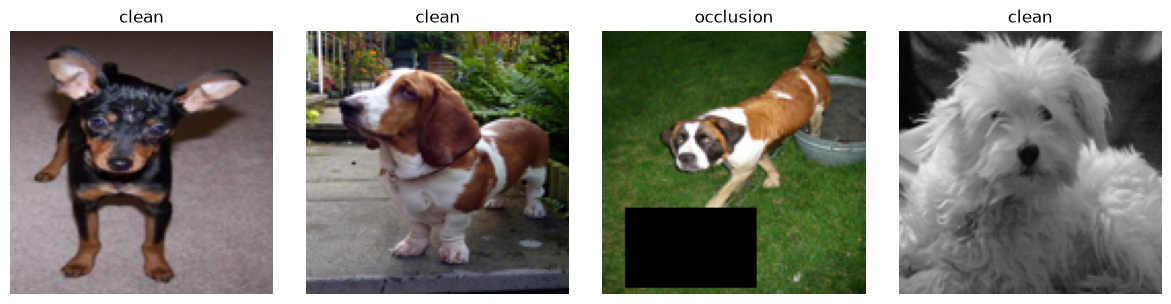

In [3]:
sample_x, sample_y = next(iter(DataLoader(train_cls_ds, batch_size=4, shuffle=True)))
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sample_x[i].permute(1, 2, 0))
    ax.set_title(CLASSES[int(sample_y[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Convolutional corruption classifier

In [4]:
def norm_layer(channels):
    groups = min(8, channels)
    while channels % groups:
        groups -= 1
    return nn.GroupNorm(groups, channels)


class CorruptionClassifier(nn.Module):
    def __init__(self, base_channels=32, dropout=0.2, num_classes=4):
        super().__init__()
        c1, c2, c3, c4 = (
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
        )

        def block(a, b):
            return nn.Sequential(
                nn.Conv2d(a, b, 4, 2, 1), norm_layer(b), nn.ReLU(inplace=True)
            )

        self.features = nn.Sequential(
            block(3, c1),
            block(c1, c2),
            block(c2, c3),
            block(c3, c4),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Linear(c4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))


def classifier_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total = correct = count = 0
    criterion = nn.CrossEntropyLoss()
    with torch.set_grad_enabled(training):
        for batch in loader:
            x = batch[0].to(device)
            y = (batch[2] if len(batch) > 2 else batch[1]).to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            if training:
                loss.backward()
                optimizer.step()
            total += float(loss) * len(y)
            correct += int((logits.argmax(1) == y).sum())
            count += len(y)
    return {"loss": total / max(1, count), "accuracy": correct / max(1, count)}


val_cls_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


## 5. Optuna search and final classifier training

The search tunes learning rate, batch size, convolution width, dropout, and weight decay. Balanced validation accuracy is the selection objective.

[I 2026-10-04 01:33:29,252] A new study created in memory with name: no-name-8e3c5658-74c7-46f6-9a97-d4794fbcf7ca
/tmp/ipykernel_57282/2541827617.py:23: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  total+=float(loss)*len(y); correct+=int((logits.argmax(1)==y).sum()); count+=len(y)
[I 2026-10-04 01:35:59,575] Trial 0 finished with value: 0.9911684782608695 and parameters: {'lr': 0.0005611516415334506, 'batch_size': 32, 'base_channels': 16, 'dropout': 0.4330880728874676, 'weight_decay': 0.00015930522616241006}. Best is trial 0 with value: 0.9911684782608695.
[I 2026-10-04 01:38:24,772] Trial 1 finished with value: 0.9894701086956522 and parameters: {'lr': 0.0026070247583707684, 'batch_size': 64, 'base_channels': 16, 'dropout': 0.15212112147976886, 'weight_decay': 0.0001120760621186057

Completed trials: 20
Best trial: 11 balanced validation accuracy: 0.9928668478260869
Selected: {'lr': 0.00044331902330616805, 'batch_size': 32, 'base_channels': 16, 'dropout': 0.31310385808137176, 'weight_decay': 0.00019448553647326953}
Epoch 01/35: train loss=0.3856 val acc=0.9395
Epoch 02/35: train loss=0.1177 val acc=0.9820
Epoch 03/35: train loss=0.0727 val acc=0.9854
Epoch 04/35: train loss=0.0530 val acc=0.9901
Epoch 05/35: train loss=0.0491 val acc=0.9854
Epoch 06/35: train loss=0.0362 val acc=0.9942
Epoch 07/35: train loss=0.0345 val acc=0.9925
Epoch 08/35: train loss=0.0359 val acc=0.9881
Epoch 09/35: train loss=0.0286 val acc=0.9949
Epoch 10/35: train loss=0.0376 val acc=0.9885
Epoch 11/35: train loss=0.0280 val acc=0.9895
Epoch 12/35: train loss=0.0269 val acc=0.9963
Epoch 13/35: train loss=0.0281 val acc=0.9851
Epoch 14/35: train loss=0.0187 val acc=0.9606
Epoch 15/35: train loss=0.0242 val acc=0.9922
Epoch 16/35: train loss=0.0328 val acc=0.9922
Epoch 17/35: train loss=0.0

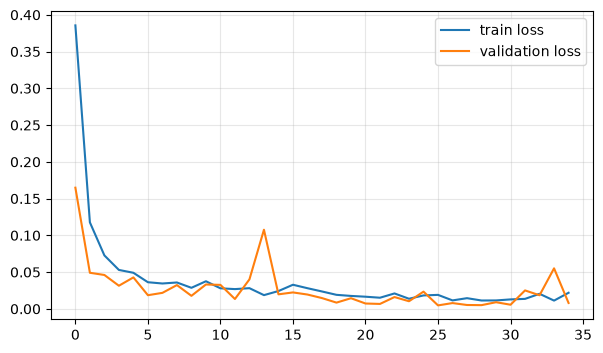

In [5]:
def classifier_objective(trial):
    p = {
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "base_channels": trial.suggest_categorical("base_channels", [16, 32, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }
    tr = DataLoader(
        train_cls_ds,
        batch_sampler=BalancedBatchSampler(train_cls_ds, p["batch_size"]),
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    vl = DataLoader(
        val_ds,
        batch_size=p["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    net = CorruptionClassifier(p["base_channels"], p["dropout"]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    best = 0.0
    for _ in range(CLASSIFIER_SEARCH_EPOCHS):
        classifier_epoch(net, tr, opt)
        best = max(best, classifier_epoch(net, vl)["accuracy"])
    return best


classifier_study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED)
)
classifier_study.optimize(classifier_objective, n_trials=N_CLASSIFIER_TRIALS)
classifier_params = classifier_study.best_params
print(
    "Completed trials:",
    len(classifier_study.get_trials(states=(optuna.trial.TrialState.COMPLETE,))),
)
print(
    "Best trial:",
    classifier_study.best_trial.number,
    "balanced validation accuracy:",
    classifier_study.best_value,
)
print("Selected:", classifier_params)

train_cls_loader = DataLoader(
    train_cls_ds,
    batch_sampler=BalancedBatchSampler(train_cls_ds, classifier_params["batch_size"]),
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_cls_loader = DataLoader(
    val_ds,
    batch_size=classifier_params["batch_size"],
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
classifier = CorruptionClassifier(
    classifier_params["base_channels"], classifier_params["dropout"]
).to(device)
classifier_opt = torch.optim.Adam(
    classifier.parameters(),
    lr=classifier_params["lr"],
    weight_decay=classifier_params["weight_decay"],
)
classifier_history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
best_acc = -1.0
best_classifier_state = None
for epoch in range(1, CLASSIFIER_FINAL_EPOCHS + 1):
    tr = classifier_epoch(classifier, train_cls_loader, classifier_opt)
    va = classifier_epoch(classifier, val_cls_loader)
    classifier_history["train_loss"].append(tr["loss"])
    classifier_history["val_loss"].append(va["loss"])
    classifier_history["val_accuracy"].append(va["accuracy"])
    if va["accuracy"] > best_acc:
        best_acc = va["accuracy"]
        best_classifier_state = copy.deepcopy(classifier.state_dict())
    print(
        f"Epoch {epoch:02d}/{CLASSIFIER_FINAL_EPOCHS}: train loss={tr['loss']:.4f} val acc={va['accuracy']:.4f}"
    )
classifier.load_state_dict(best_classifier_state)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(classifier_history["train_loss"], label="train loss")
ax.plot(classifier_history["val_loss"], label="validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 6. Classifier metrics and normalized confusion matrix

Validation report: {
  "accuracy": 0.9989809782608695,
  "macro_precision": 0.9989851150202977,
  "macro_recall": 0.9989809782608696,
  "macro_f1": 0.9989809740282216,
  "per_class": [
    {
      "class": "clean",
      "precision": 0.9959404600811907,
      "recall": 1.0,
      "f1": 0.9979661016949152,
      "support": 736
    },
    {
      "class": "salt",
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 736
    },
    {
      "class": "blur",
      "precision": 1.0,
      "recall": 0.9959239130434783,
      "f1": 0.9979577944179714,
      "support": 736
    },
    {
      "class": "occlusion",
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 736
    }
  ],
  "confusion_matrix": [
    [
      736,
      0,
      0,
      0
    ],
    [
      0,
      736,
      0,
      0
    ],
    [
      3,
      0,
      733,
      0
    ],
    [
      0,
      0,
      0,
      736
    ]
  ],
  "normalized_confusion_matrix": [
    [


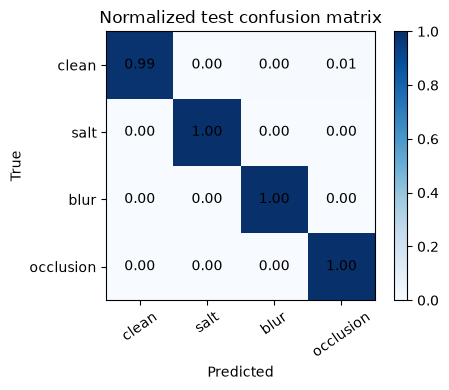

In [6]:
@torch.inference_mode()
def classifier_predictions(model, loader):
    model.eval()
    ys = []
    ps = []
    probs = []
    for batch in loader:
        x = batch[0].to(device)
        y = (batch[2] if len(batch) > 2 else batch[1]).to(device)
        logits = model(x)
        ys.extend(y.cpu().tolist())
        ps.extend(logits.argmax(1).cpu().tolist())
        probs.extend(logits.softmax(1).cpu().tolist())
    return np.asarray(ys), np.asarray(ps), np.asarray(probs)


def classification_summary(y_true, y_pred):
    cm = np.zeros((4, 4), dtype=np.int64)
    for a, b in zip(y_true, y_pred):
        cm[a, b] += 1
    per_class = []
    for k, name in enumerate(CLASSES):
        tp = cm[k, k]
        precision = tp / max(1, cm[:, k].sum())
        recall = tp / max(1, cm[k, :].sum())
        f1 = 2 * precision * recall / max(1e-12, precision + recall)
        per_class.append(
            {
                "class": name,
                "precision": float(precision),
                "recall": float(recall),
                "f1": float(f1),
                "support": int(cm[k, :].sum()),
            }
        )
    norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    return {
        "accuracy": float((y_true == y_pred).mean()),
        "macro_precision": float(np.mean([r["precision"] for r in per_class])),
        "macro_recall": float(np.mean([r["recall"] for r in per_class])),
        "macro_f1": float(np.mean([r["f1"] for r in per_class])),
        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
        "normalized_confusion_matrix": norm.tolist(),
    }


yv, pv, _ = classifier_predictions(classifier, val_cls_loader)
val_classifier_report = classification_summary(yv, pv)
yt, pt, prob_t = classifier_predictions(
    classifier,
    DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
)
test_classifier_report = classification_summary(yt, pt)
print("Validation report:", json.dumps(val_classifier_report, indent=2))
print("Test report:", json.dumps(test_classifier_report, indent=2))
plt.figure(figsize=(5, 4))
plt.imshow(
    test_classifier_report["normalized_confusion_matrix"], vmin=0, vmax=1, cmap="Blues"
)
plt.xticks(range(4), CLASSES, rotation=35)
plt.yticks(range(4), CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized test confusion matrix")
plt.colorbar()
for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            f"{test_classifier_report['normalized_confusion_matrix'][i][j]:.2f}",
            ha="center",
            va="center",
        )
plt.tight_layout()
plt.show()


## 7. Specialist autoencoder, composite loss, and training helpers

All three experts share a searched architecture but are trained independently. Each encoder compresses the image to a fully connected latent vector; there are no skip connections.

In [7]:
class ConvDAE(nn.Module):
    def __init__(self, base_channels=32, latent_dim=128, dropout=0.1):
        super().__init__()
        c1, c2, c3, c4, c5 = (
            base_channels,
            base_channels * 2,
            base_channels * 4,
            base_channels * 8,
            base_channels * 8,
        )
        self.c5 = c5

        def down(a, b, drop):
            return nn.Sequential(
                nn.Conv2d(a, b, 4, 2, 1),
                norm_layer(b),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(dropout) if drop and dropout else nn.Identity(),
            )

        self.enc = nn.Sequential(
            down(3, c1, True),
            down(c1, c2, True),
            down(c2, c3, True),
            down(c3, c4, False),
            down(c4, c5, False),
        )
        self.fc_z = nn.Linear(c5 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, c5 * 4 * 4)

        def up(a, b, final=False):
            layer = [
                nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
                nn.Conv2d(a, b, 3, padding=1),
            ]
            layer += (
                [nn.Sigmoid()]
                if final
                else [norm_layer(b), nn.LeakyReLU(0.2, inplace=True)]
            )
            return nn.Sequential(*layer)

        self.dec = nn.Sequential(
            up(c5, c4), up(c4, c3), up(c3, c2), up(c2, c1), up(c1, 3, True)
        )

    def forward(self, x):
        h = self.enc(x)
        z = self.fc_z(torch.flatten(h, 1))
        h = self.fc_dec(z).view(-1, self.c5, 4, 4)
        return self.dec(h)


def dae_loss(pred, target, alpha):
    l1 = F.l1_loss(pred, target)
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return alpha * l1 + (1 - alpha) * (1 - ssim)


def dae_epoch(model, loader, optimizer=None, alpha=0.8):
    training = optimizer is not None
    model.train(training)
    total = count = 0
    with torch.set_grad_enabled(training):
        for x, clean, *_ in loader:
            x, clean = x.to(device), clean.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            pred = model(x)
            loss = dae_loss(pred, clean, alpha)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += float(loss) * len(clean)
            count += len(clean)
    return total / max(1, count)


def make_specialist_train(names, kind):
    class SpecialistTrainDataset(Dataset):
        def __len__(self):
            return len(names)

        def __getitem__(self, idx):
            clean = image_tensor(names[idx])
            params = sample_train_params(random, kind)
            return apply_corruption(clean, params), clean

    return SpecialistTrainDataset()


## 8. Optuna shared specialist search

The shared search follows the assignment's compute-feasible option: tune on the salt specialist, then use the selected learning rate, batch size, bottleneck, channels, dropout, and L1/SSIM weight for three independent full training runs. The blur and occlusion experts still receive their own domain-specific training data and parameters.

In [8]:
salt_train_ds = make_specialist_train(train_names, "salt")
salt_val_ds = FixedDataset(val_names, val_manifest, kind="salt")


def specialist_objective(trial):
    p = {
        "lr": trial.suggest_float("lr", 1e-4, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "latent_dim": trial.suggest_categorical("latent_dim", [64, 128, 256]),
        "base_channels": trial.suggest_categorical("base_channels", [16, 32, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.3),
        "alpha": trial.suggest_float("alpha", 0.5, 0.95),
    }
    tr = DataLoader(
        salt_train_ds,
        batch_size=p["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    vl = DataLoader(
        salt_val_ds,
        batch_size=p["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    net = ConvDAE(p["base_channels"], p["latent_dim"], p["dropout"]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=p["lr"])
    best = float("inf")
    for _ in range(SPECIALIST_SEARCH_EPOCHS):
        dae_epoch(net, tr, opt, p["alpha"])
        best = min(best, dae_epoch(net, vl, None, p["alpha"]))
    return best


specialist_study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED + 1)
)
specialist_study.optimize(specialist_objective, n_trials=N_SPECIALIST_TRIALS)
specialist_params = specialist_study.best_params
print(
    "Completed trials:",
    len(specialist_study.get_trials(states=(optuna.trial.TrialState.COMPLETE,))),
)
print(
    "Best trial:",
    specialist_study.best_trial.number,
    "validation objective:",
    specialist_study.best_value,
)
print("Shared specialist configuration:", specialist_params)


[I 2026-10-04 02:39:47,022] A new study created in memory with name: no-name-330f4d83-d7d3-4c3f-a216-cd7b770bad21
/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
[I 2026-10-04 02:40:36,301] Trial 0 finished with value: 0.17759588004454321 and parameters: {'lr': 0.0001303330523507183, 'batch_size': 16, 'latent_dim': 128, 'base_channels': 64, 'dropout': 0.11848500552930175, 'alpha': 0.8609212033828999}. Best is trial 0 with value: 0.17759588004454321.
[I 2026-10-04 02:41:23,341] Trial 1 finished with value: 0.15140392080597256 and parameters: {'lr': 0.00017964747848196538, 'batch_size': 32, 'latent_dim': 64, 'base_channels': 64, 'dropout': 0.11561307431854143, 'alpha': 0.9295196562988993}. Best is trial 1 with value: 0.1514039208

Completed trials: 20
Best trial: 11 validation objective: 0.14697126396324323
Shared specialist configuration: {'lr': 0.00043229972191779483, 'batch_size': 32, 'latent_dim': 64, 'base_channels': 64, 'dropout': 0.10815425288185826, 'alpha': 0.9453915215892892}


## 9. Train salt, blur, and occlusion specialists independently


Training independent salt expert
Epoch 01/35: train=0.2222 val=0.1923
Epoch 02/35: train=0.1777 val=0.1687
Epoch 03/35: train=0.1627 val=0.1540
Epoch 04/35: train=0.1521 val=0.1490
Epoch 05/35: train=0.1484 val=0.1461
Epoch 06/35: train=0.1454 val=0.1434
Epoch 07/35: train=0.1430 val=0.1431
Epoch 08/35: train=0.1409 val=0.1392
Epoch 09/35: train=0.1394 val=0.1388
Epoch 10/35: train=0.1371 val=0.1368
Epoch 11/35: train=0.1356 val=0.1353
Epoch 12/35: train=0.1346 val=0.1383
Epoch 13/35: train=0.1348 val=0.1348
Epoch 14/35: train=0.1329 val=0.1345
Epoch 15/35: train=0.1316 val=0.1320
Epoch 16/35: train=0.1310 val=0.1324
Epoch 17/35: train=0.1308 val=0.1325
Epoch 18/35: train=0.1296 val=0.1310
Epoch 19/35: train=0.1286 val=0.1301
Epoch 20/35: train=0.1290 val=0.1301
Epoch 21/35: train=0.1277 val=0.1292
Epoch 22/35: train=0.1271 val=0.1291
Epoch 23/35: train=0.1261 val=0.1285
Epoch 24/35: train=0.1253 val=0.1277
Epoch 25/35: train=0.1247 val=0.1277
Epoch 26/35: train=0.1242 val=0.1284
Epoc

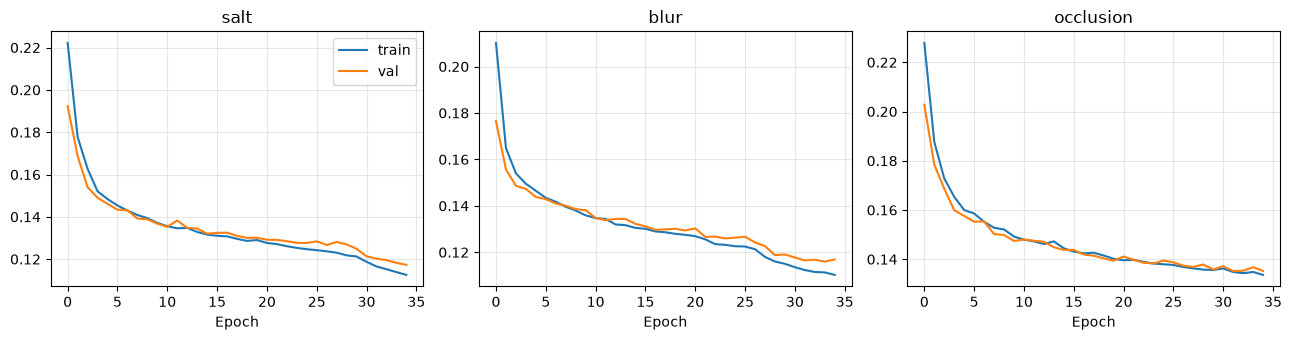

In [9]:
CHECKPOINT_DIR = RESEARCH_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
specialists = {}
specialist_histories = {}
specialist_val_metrics = {}
for kind in RESTORATION_CLASSES:
    print(f"\nTraining independent {kind} expert")
    train_ds = make_specialist_train(train_names, kind)
    valid_ds = FixedDataset(val_names, val_manifest, kind=kind)
    tr = DataLoader(
        train_ds,
        batch_size=specialist_params["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    vl = DataLoader(
        valid_ds,
        batch_size=specialist_params["batch_size"],
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    model = ConvDAE(
        specialist_params["base_channels"],
        specialist_params["latent_dim"],
        specialist_params["dropout"],
    ).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=specialist_params["lr"])
    best = float("inf")
    best_state = None
    hist = {"train": [], "val": []}
    for epoch in range(1, SPECIALIST_FINAL_EPOCHS + 1):
        train_loss = dae_epoch(model, tr, opt, specialist_params["alpha"])
        val_loss = dae_epoch(model, vl, None, specialist_params["alpha"])
        hist["train"].append(train_loss)
        hist["val"].append(val_loss)
        if val_loss < best:
            best = val_loss
            best_state = copy.deepcopy(model.state_dict())
        print(
            f"Epoch {epoch:02d}/{SPECIALIST_FINAL_EPOCHS}: train={train_loss:.4f} val={val_loss:.4f}"
        )
    model.load_state_dict(best_state)
    specialists[kind] = model
    specialist_histories[kind] = hist
    specialist_val_metrics[kind] = best
    torch.save(
        {
            "state_dict": model.state_dict(),
            "architecture": specialist_params,
            "corruption_type": kind,
            "seed": SEED,
        },
        CHECKPOINT_DIR / f"task2_standalone_specialist_{kind}_best.pt",
    )
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, kind in zip(axes, RESTORATION_CLASSES):
    ax.plot(specialist_histories[kind]["train"], label="train")
    ax.plot(specialist_histories[kind]["val"], label="val")
    ax.set_title(kind)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Oracle and predicted hard-routing evaluation

Oracle routing uses the known manifest label. Predicted routing uses the classifier. The clean class passes the input through unchanged; only a predicted salt, blur, or occlusion class invokes an expert. Metrics are grouped by true corruption and severity.

In [10]:
def quality(pred, target):
    pred = pred.clamp(0, 1)
    mse = (pred - target).square().flatten(1).mean(1).clamp_min(1e-10)
    psnr = 10 * torch.log10(1.0 / mse)
    ssim = torch.stack(
        [
            structural_similarity_index_measure(
                pred[i : i + 1], target[i : i + 1], data_range=1.0
            )
            for i in range(len(pred))
        ]
    )
    return psnr, ssim


@torch.inference_mode()
def hard_route_evaluate(classifier, specialists, dataset):
    classifier.eval()
    [m.eval() for m in specialists.values()]
    rows = []
    mistakes = []
    for idx in range(len(dataset)):
        x, clean, label, name, kind, severity = dataset[idx]
        logits = classifier(x.unsqueeze(0).to(device))
        probs = logits.softmax(1)[0].cpu().numpy()
        predicted = int(logits.argmax(1).item())
        oracle_kind = CLASSES[label]
        pred_kind = CLASSES[predicted]
        oracle_out = (
            x.unsqueeze(0).to(device)
            if oracle_kind == "clean"
            else specialists[oracle_kind](x.unsqueeze(0).to(device))
        )
        pred_out = (
            x.unsqueeze(0).to(device)
            if pred_kind == "clean"
            else specialists[pred_kind](x.unsqueeze(0).to(device))
        )
        op, os = quality(oracle_out, clean.unsqueeze(0).to(device))
        pp, ps = quality(pred_out, clean.unsqueeze(0).to(device))
        rows.append(
            {
                "filename": name,
                "corruption": kind,
                "severity": severity,
                "true_class": oracle_kind,
                "predicted_class": pred_kind,
                "probabilities": probs.tolist(),
                "oracle_psnr": float(op[0]),
                "oracle_ssim": float(os[0]),
                "predicted_psnr": float(pp[0]),
                "predicted_ssim": float(ps[0]),
                "classifier_correct": predicted == label,
            }
        )
        if predicted != label:
            mistakes.append(rows[-1])
    return rows, mistakes


routing_rows, routing_mistakes = hard_route_evaluate(classifier, specialists, test_ds)


def grouped_routing(rows, mode):
    groups = {}
    for r in rows:
        key = (r["corruption"], r["severity"])
        groups.setdefault(key, []).append(r)
    out = []
    for (kind, sev), items in sorted(groups.items()):
        out.append(
            {
                "corruption": kind,
                "severity": sev,
                "n": len(items),
                "PSNR": float(np.mean([r[f"{mode}_psnr"] for r in items])),
                "SSIM": float(np.mean([r[f"{mode}_ssim"] for r in items])),
            }
        )
    return out


oracle_metrics = grouped_routing(routing_rows, "oracle")
predicted_metrics = grouped_routing(routing_rows, "predicted")
print("Oracle routing (known corruption):")
for r in oracle_metrics:
    print(r)
print("\nPredicted routing (classifier selected):")
for r in predicted_metrics:
    print(r)
print(f"\nClassifier routing errors: {len(routing_mistakes)} / {len(routing_rows)}")


Oracle routing (known corruption):
{'corruption': 'blur', 'severity': 'high', 'n': 3669, 'PSNR': 18.170394893302095, 'SSIM': 0.42141207866827585}
{'corruption': 'blur', 'severity': 'low', 'n': 3669, 'PSNR': 18.116522070821542, 'SSIM': 0.42258541090436774}
{'corruption': 'blur', 'severity': 'medium', 'n': 3669, 'PSNR': 18.153824312350963, 'SSIM': 0.42219983583885307}
{'corruption': 'clean', 'severity': 'none', 'n': 3669, 'PSNR': 100.0, 'SSIM': 0.9999967525297109}
{'corruption': 'occlusion', 'severity': 'high', 'n': 3669, 'PSNR': 16.39427261191384, 'SSIM': 0.39120940649442826}
{'corruption': 'occlusion', 'severity': 'low', 'n': 3669, 'PSNR': 16.87700674208285, 'SSIM': 0.4002320146237384}
{'corruption': 'occlusion', 'severity': 'medium', 'n': 3669, 'PSNR': 16.74181664519623, 'SSIM': 0.39742710073797083}
{'corruption': 'salt', 'severity': 'high', 'n': 3669, 'PSNR': 18.00481836501439, 'SSIM': 0.4198573370047602}
{'corruption': 'salt', 'severity': 'low', 'n': 3669, 'PSNR': 18.038914193636586

## 11. Identify routing failures and inspect representative outputs

Largest classifier-induced restoration drops:
chihuahua_84.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 8.87, drop 91.13 dB
samoyed_72.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 9.23, drop 90.77 dB
shiba_inu_95.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 9.83, drop 90.17 dB
basset_hound_99.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 12.02, drop 87.98 dB
Sphynx_245.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 12.33, drop 87.67 dB
Persian_271.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 12.63, drop 87.37 dB
Egyptian_Mau_60.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 12.72, drop 87.28 dB
staffordshire_bull_terrier_29.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 13.30, drop 86.70 dB
chihuahua_60.jpg clean/none: predicted occlusion, oracle PSNR 100.00, routed PSNR 13.93, drop 86.07 dB
german_short

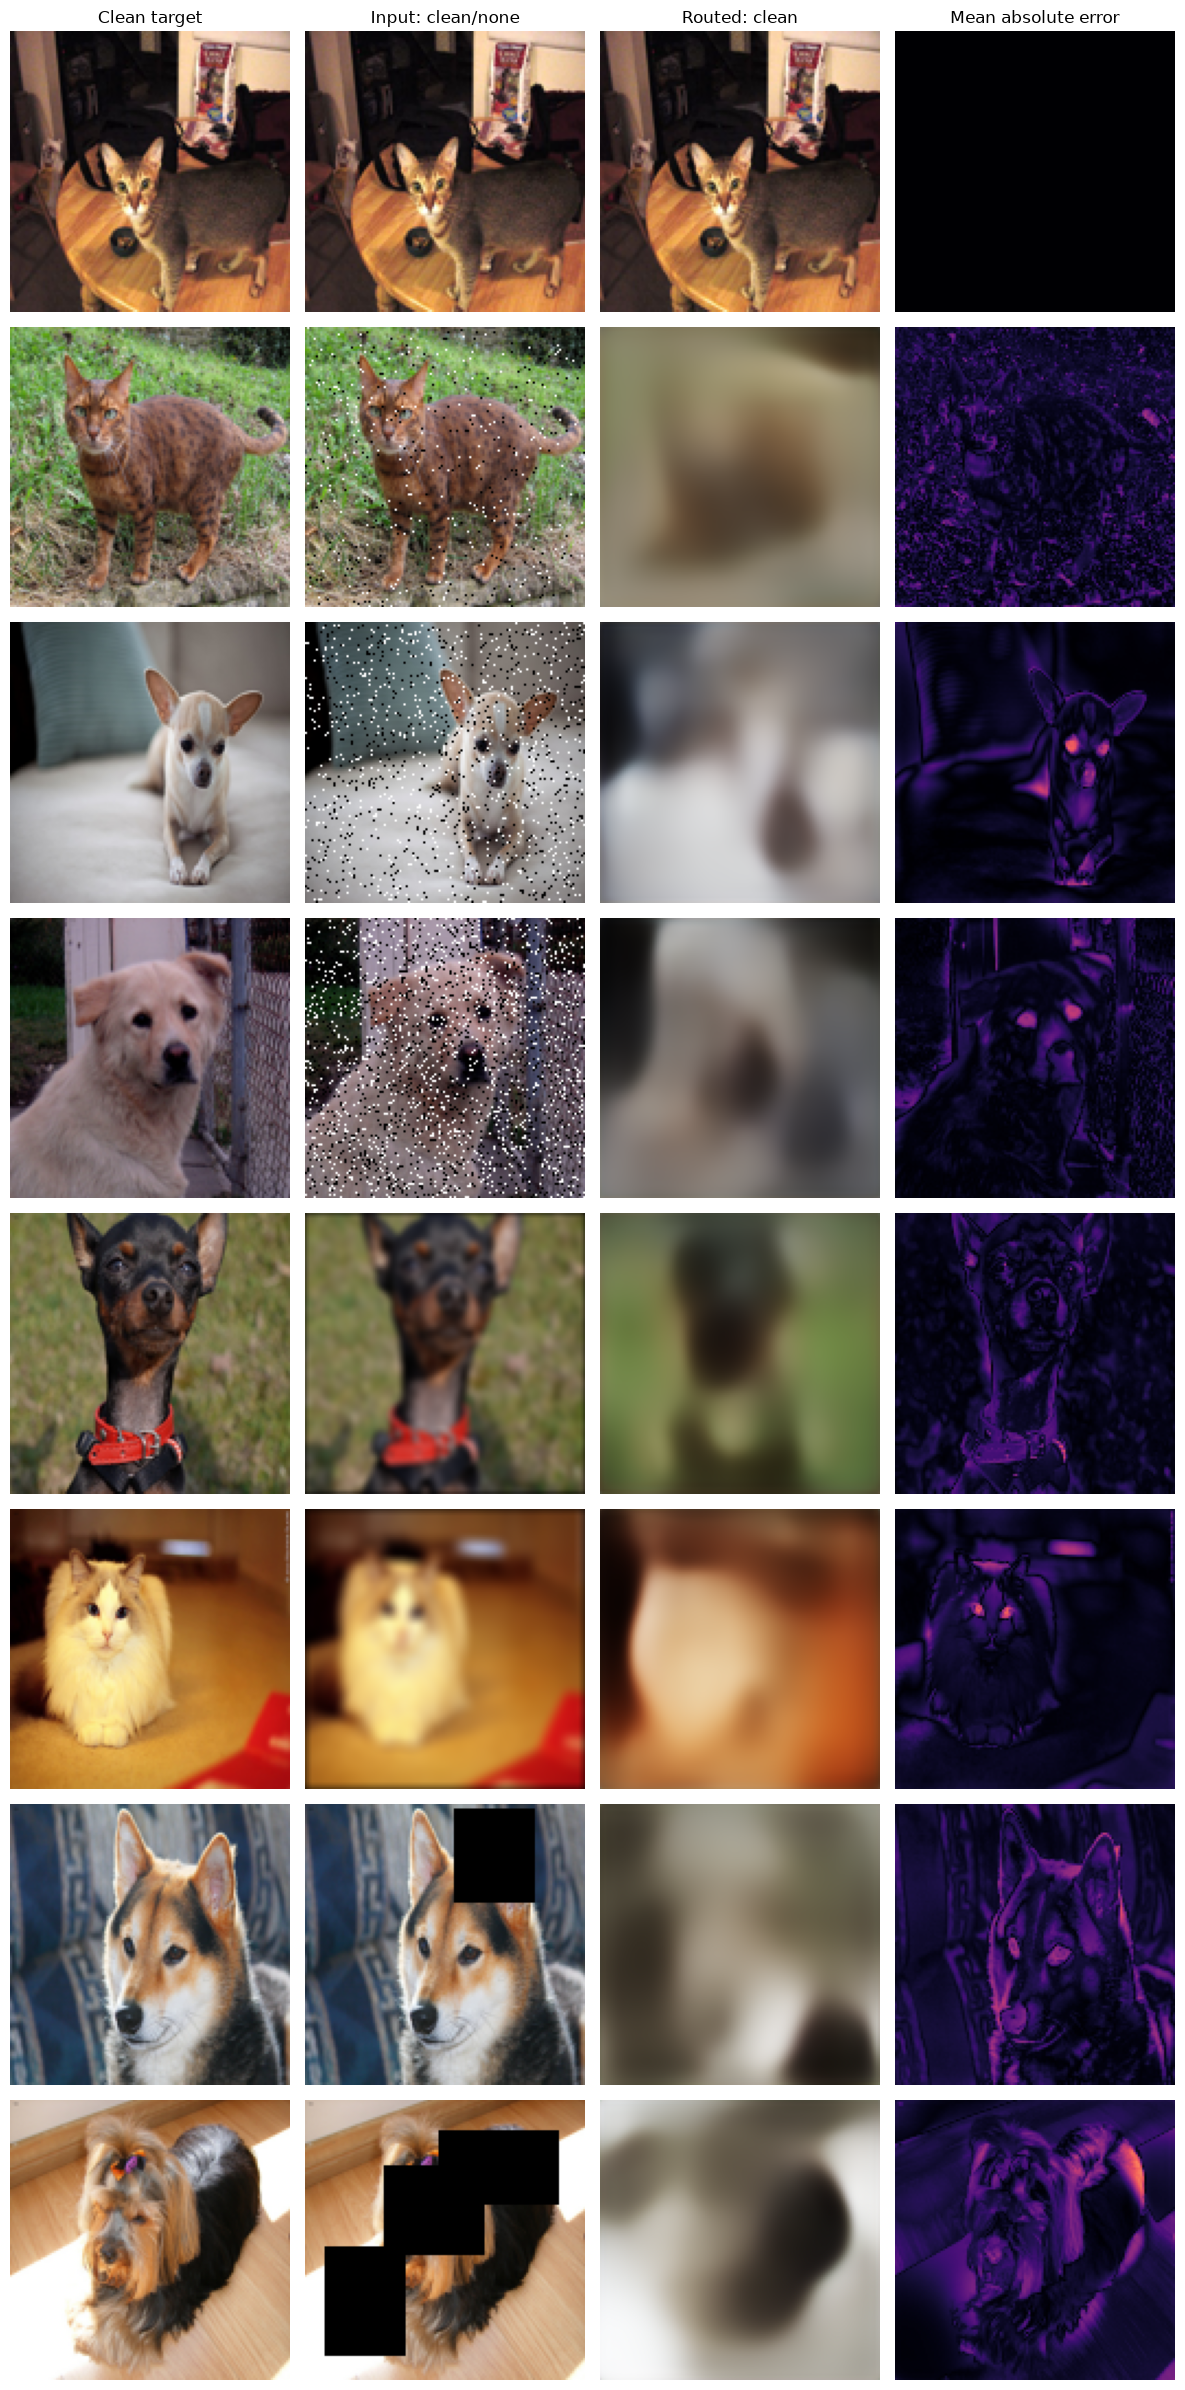

In [11]:
# Rank misrouted cases by the oracle-to-predicted PSNR drop.
for r in routing_mistakes:
    r["psnr_drop_from_routing_error"] = r["oracle_psnr"] - r["predicted_psnr"]
routing_mistakes.sort(key=lambda r: r["psnr_drop_from_routing_error"], reverse=True)
print("Largest classifier-induced restoration drops:")
for r in routing_mistakes[:10]:
    print(
        f"{r['filename']} {r['corruption']}/{r['severity']}: predicted {r['predicted_class']}, oracle PSNR {r['oracle_psnr']:.2f}, routed PSNR {r['predicted_psnr']:.2f}, drop {r['psnr_drop_from_routing_error']:.2f} dB"
    )


@torch.inference_mode()
def show_examples(model_classifier, experts, dataset, indices):
    fig, axes = plt.subplots(
        len(indices), 4, figsize=(12, 3 * len(indices)), squeeze=False
    )
    for row, idx in enumerate(indices):
        x, clean, label, name, kind, severity = dataset[idx]
        pred_class = int(model_classifier(x.unsqueeze(0).to(device)).argmax(1).item())
        selected = CLASSES[pred_class]
        restored = (
            x
            if selected == "clean"
            else experts[selected](x.unsqueeze(0).to(device))[0].cpu()
        )
        for col, (im, title) in enumerate(
            [
                (clean, "Clean target"),
                (x, f"Input: {kind}/{severity}"),
                (restored, f"Routed: {selected}"),
                ((clean - restored).abs().mean(0), "Mean absolute error"),
            ]
        ):
            axes[row, col].imshow(
                im.permute(1, 2, 0) if im.ndim == 3 else im,
                cmap="magma" if col == 3 else None,
                vmin=0 if col == 3 else None,
                vmax=1 if col == 3 else None,
            )
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(title)
        axes[row, 0].set_ylabel(f"{name}\ntrue={kind}", fontsize=8)
    plt.tight_layout()
    plt.show()


show_indices = np.linspace(
    0, len(test_ds) - 1, min(8, len(test_ds)), dtype=int
).tolist()
show_examples(classifier, specialists, test_ds, show_indices)


## 12. Save checkpoints, manifests, and run summary

Review the classifier mistakes and specialist quality by corruption and severity when writing the report. Oracle metrics isolate expert quality; predicted-routing metrics measure the complete operational pipeline.

In [12]:
torch.save(
    {
        "state_dict": classifier.state_dict(),
        "architecture": {k: classifier_params[k] for k in ("base_channels", "dropout")},
        "class_order": CLASSES,
        "seed": SEED,
    },
    CHECKPOINT_DIR / "task2_standalone_classifier_best.pt",
)
REPORT_PATH = RESEARCH_ROOT / "reports" / "task2_standalone_metrics.json"
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
report = {
    "classifier": {
        "best_trial": int(classifier_study.best_trial.number),
        "completed_trials": len(
            classifier_study.get_trials(states=(optuna.trial.TrialState.COMPLETE,))
        ),
        "best_validation_accuracy": float(classifier_study.best_value),
        "best_params": classifier_params,
        "validation_metrics": val_classifier_report,
        "test_metrics": test_classifier_report,
    },
    "specialists": {
        "best_trial": int(specialist_study.best_trial.number),
        "completed_trials": len(
            specialist_study.get_trials(states=(optuna.trial.TrialState.COMPLETE,))
        ),
        "best_validation_objective": float(specialist_study.best_value),
        "shared_params": specialist_params,
        "independent_validation_objectives": specialist_val_metrics,
        "trained_experts": list(RESTORATION_CLASSES),
    },
    "routing": {
        "oracle_metrics": oracle_metrics,
        "predicted_metrics": predicted_metrics,
        "classifier_routing_errors": len(routing_mistakes),
        "routing_cases": routing_rows,
        "largest_routing_failures": routing_mistakes[:20],
    },
    "manifests": {
        "validation": str(VAL_MANIFEST_PATH),
        "test": str(TEST_MANIFEST_PATH),
    },
    "seed": SEED,
    "tiny_run": TINY_RUN,
}
REPORT_PATH.write_text(json.dumps(report, indent=2))
print("Saved classifier and three specialist checkpoints under", CHECKPOINT_DIR)
print("Saved run summary:", REPORT_PATH)


Saved classifier and three specialist checkpoints under /home/zaifi/genai-assignment-1/research/checkpoints
Saved run summary: /home/zaifi/genai-assignment-1/research/reports/task2_standalone_metrics.json
